# Network Analysis
## Lab 2
### Network Types and Statistics

In this lab, we will expand upon the capabilities of `igraph` to construct special types or networks and calculate network statistics. Similar to before, we maintain a small running example that lets us visualize everything, before moving to a more complex application setting. In this lab, we will:
- construct different types of networks,
- compute basic network statistics,
- understand paths, components, and distances,
- interpret these concepts using examples.

In [2]:
# Load installed packages
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

### Special network types

We consider the same network structure as we did in class:
- Complete
- Trees
- Stars
- Lattices
- Bipartite

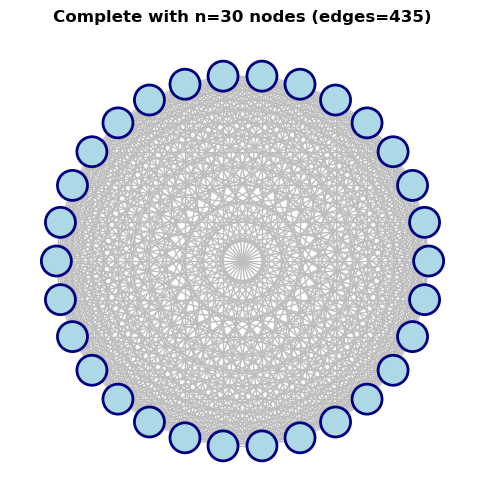

In [9]:
# Complete network on n nodes using a generic function
def complete_graph(n, layout_type='circle'):
    # Create complete graph with n nodes
    g = ig.Graph.Full(n)
    
    # Plot
    _, ax = plt.subplots(figsize=(6,6))
    ig.plot(
        g,
        target=ax,
        layout=layout_type,
        vertex_size=30,
        vertex_color='lightblue',
        vertex_frame_width=2,
        vertex_frame_color='navy',
        edge_width=1,
        edge_color='gray',
        margin=40
    )
    
    # Add title with graph properties
    edges_count = g.ecount()
    ax.set_title(f'Complete with n={n} nodes (edges={edges_count})',
                 fontsize=12, fontweight='bold')

# Use the function to create and plot complete graphs
layouts = ['circle', 'grid', 'sphere', 'fruchterman_reingold']
n = 30
layout_choice = 0  # Change index to try different layouts
complete_graph(n, layout_type=layouts[layout_choice])

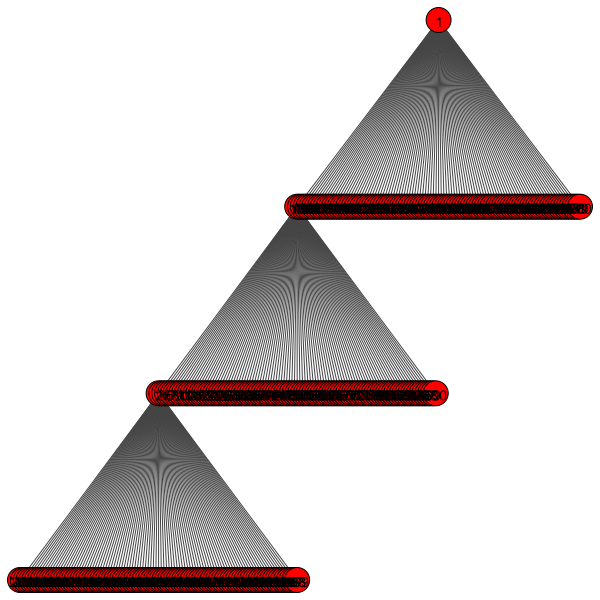

In [19]:
# Tree graphs: acyclic connected graphs
n = 300
children = 100
tree = ig.Graph.Tree(n=n, children=children, mode="undirected")

ig.plot(
    tree,
    layout="rt",
    vertex_label=list(range(n)),
    vertex_size=25
)

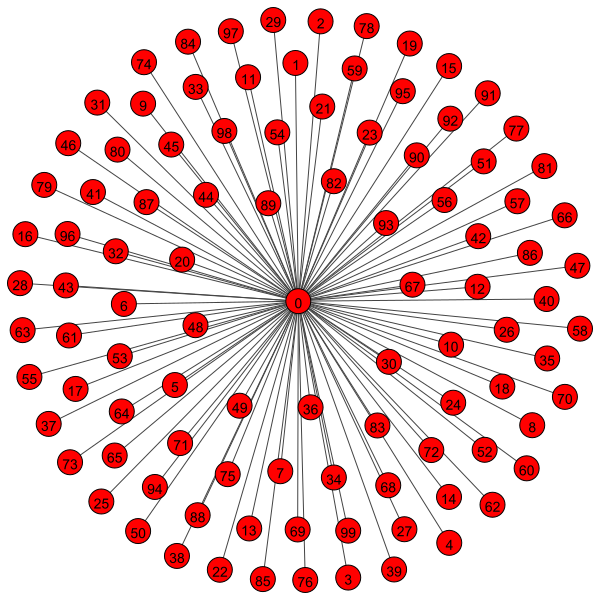

In [21]:
# Stars
n = 100
star = ig.Graph.Star(n=n, mode=ig.STAR_UNDIRECTED)
layout_type = 'fr' # "circle" # "fruchterman_reingold"

ig.plot(
    star,
    layout=layout_type,
    vertex_label=list(range(n)),
    vertex_size=25
)

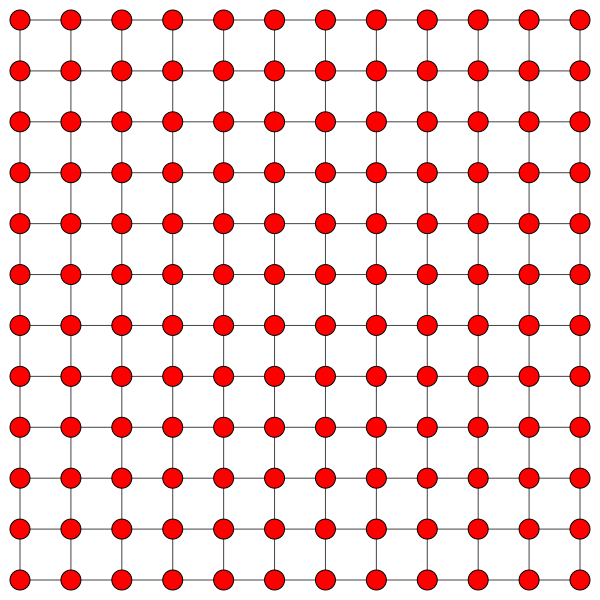

In [25]:
# Lattices
x_dim = 12
y_dim = 12
circular = False
layout_type = 'circle' if circular else 'grid'
lattice = ig.Graph.Lattice(dim=[x_dim,y_dim], circular=circular)

ig.plot(
    lattice,
    layout=layout_type,
    vertex_size=20
)


In [34]:
# Bipartite graphs
bip = ig.Graph.Bipartite(
    types=[0,0,0,0,0,0,1,1,1,1,1,1],
    edges=[(0,6), (0,7), (1,7), (2,8)]
)

ig.plot(
    bip,
    layout=bip.layout_bipartite(),
    vertex_color=["lightblue" if t == 0 else "salmon" for t in bip.vs["type"]],
    vertex_size=25
)

# Random bipartite graph
n1 = 25
n2 = 12
g_random = ig.Graph.Bipartite(
    types=[False]*n1 + [True]*n2,
    edges=[(i, j) for i in range(n1) for j in range(n1, n1 + n2) if np.random.uniform() < 0.4]
)

ig.plot(
    g_random,
    layout=g_random.layout_bipartite(),
    vertex_color=["lightblue" if t == False else "salmon" for t in g_random.vs["type"]],
    vertex_size=25
)
print(g_random.density())

0.17117117117117117


### A running example network

We begin with a small network where all statistics can be computed by hand.

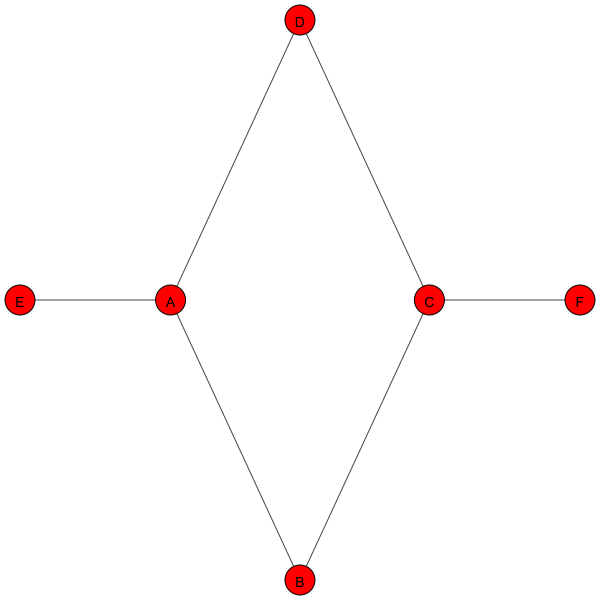

In [35]:
# Create and plot a simple undirected graph
g = ig.Graph(
    edges=[
        (0,1), (1,2), (2,3), (3,0),  # cycle
        (0,4),                      # branch
        (2,5)                       # branch
    ],
    directed=False
)
g.vs["name"] = ["A", "B", "C", "D", "E", "F"]
ig.plot(
    g,
    layout="fr",
    vertex_label=g.vs["name"],
    vertex_size=30
)

### Calculate network statistics

We will calculate the network measures we discussed during the class:
- Degree and weighted degree
- Walks, paths and cycles
- Connectedness and disconnected components
- Distances and diameter

[('A', 3), ('B', 2), ('C', 3), ('D', 2), ('E', 1), ('F', 1)]
Weighted adjacency matrix:
 [[0 1 0 1 3 0]
 [1 0 2 0 0 0]
 [0 2 0 1 0 2]
 [1 0 1 0 0 0]
 [3 0 0 0 0 0]
 [0 0 2 0 0 0]]
[('A', 5.0), ('B', 3.0), ('C', 5.0), ('D', 2.0), ('E', 3.0), ('F', 2.0)]


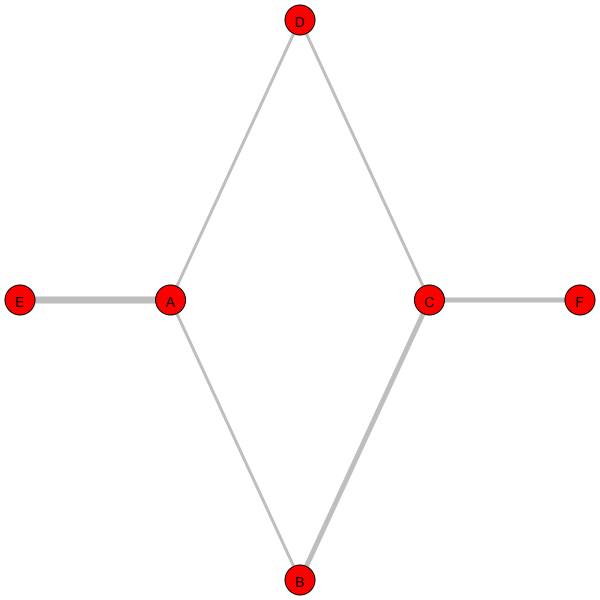

In [37]:
# Degree
degrees = g.degree()
print(list(zip(g.vs["name"], degrees)))

# Weighted degree
g.es["weight"] = [1, 2, 1, 1, 3, 2]
weighted_degree = g.strength(weights="weight")
A_weighted = g.get_adjacency(attribute="weight").data
print("Weighted adjacency matrix:\n", np.array(A_weighted))
print(list(zip(g.vs["name"], weighted_degree)))
ig.plot(
    g, 
    layout="fr",
    vertex_label=g.vs["name"],
    vertex_size=30,
    edge_width=[1 + 2*w for w in g.es["weight"]],
    edge_color="gray"
)

In [39]:
# Walks of a given order
A = np.array(g.get_adjacency().data)
A2 = np.linalg.matrix_power(A, 2)
A3 = np.linalg.matrix_power(A, 3)
print("Walks of size 2:\n", A2)
print("Walks of size 3:\n", A3)

# Paths between any two nodes
print("All paths between C and E:", g.get_all_simple_paths("E", "C"))

# Does the graph contain cycles?
print("Is the graph acyclic?", g.is_acyclic())

Walks of size 2:
 [[3 0 2 0 0 0]
 [0 2 0 2 1 1]
 [2 0 3 0 0 0]
 [0 2 0 2 1 1]
 [0 1 0 1 1 0]
 [0 1 0 1 0 1]]
Walks of size 3:
 [[0 5 0 5 3 2]
 [5 0 5 0 0 0]
 [0 5 0 5 2 3]
 [5 0 5 0 0 0]
 [3 0 2 0 0 0]
 [2 0 3 0 0 0]]
All paths between C and E: [[4, 0, 1, 2], [4, 0, 3, 2]]
Is the graph acyclic? False


True
Clustering with 6 elements and 1 clusters
[0] A, B, C, D, E, F
False
Clustering with 6 elements and 2 clusters
[0] A, D, E
[1] B, C, F


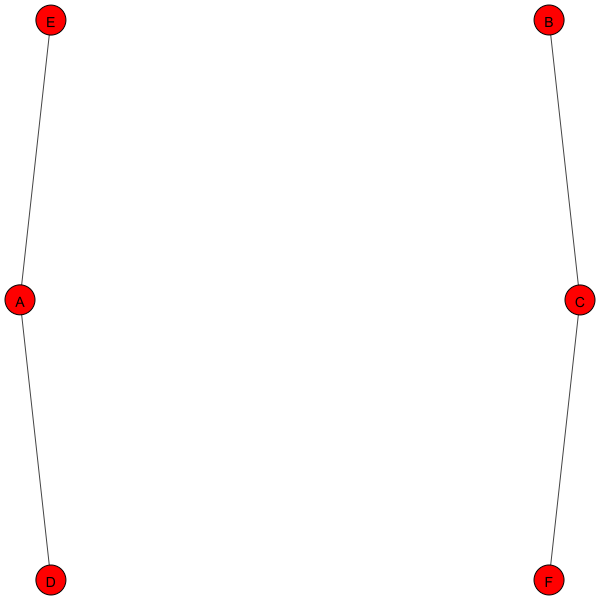

In [41]:
# Connectivity
print(g.is_connected())
print(g.components())

# Disconnected components
g2 = g.copy()
g2.delete_edges([(0,1), (2,3)])

print(g2.is_connected())
print(g2.components())
ig.plot(
    g2,
    layout="fr",
    vertex_label=g2.vs["name"],
    vertex_size=30
)

In [42]:
# Distance and diameter
distance_matrix = np.asarray(g.distances())
diameter = g.diameter()
print("Distance matrix:\n", distance_matrix)
print("Diameter:", diameter)


Distance matrix:
 [[0 1 2 1 1 3]
 [1 0 1 2 2 2]
 [2 1 0 1 3 1]
 [1 2 1 0 2 2]
 [1 2 3 2 0 4]
 [3 2 1 2 4 0]]
Diameter: 4


### Application to Input-Output networks

We will explore similar numerical statistics using a real-world input-output network for the US in 2002. Obtained from [Bureau of Economic Analysis](https://www.bea.gov/)

In [ ]:
# Load data as a Matlab .mat file
from scipy.io import loadmat

# Load .mat file
mat_data = loadmat('IO2002_data.mat')
# mat_data is a dictionary where keys are variable names
print(mat_data.keys())  # See what variables are in the file

# Access specific matrix/variable
IO_matrix = mat_data['CC02']  # Replace with actual variable name
print(IO_matrix.shape)
print(IO_matrix)

In [ ]:
# Create graph from adjacency matrix
# Assuming weighted, directed graph (common for IO networks)
g = ig.Graph.Weighted_Adjacency(
    IO_matrix.tolist(), 
    mode='directed',  # Change to 'undirected' if needed
    attr='weight'
)
